# MIMIC-III — Training (Notebook 2 of 2)

**No Spark or Java, Reads `mimic_final_matrix.parquet` produced by `1_etl_pipeline.ipynb`.**

The parquet/csv should be already fully imputed — no NaN handling is needed here.  

### Requirements
```
pip install pandas pyarrow lightgbm matplotlib dask
```

## SomeThoughts

The main challenge of predicting ICU LOS from MIMIC-iii is that the data is really right-skewed (Most patients stay in the ICU for a very short time like 2 to 3 days, but a small subset of patients will face complications like sepsis, mechanical ventilation and stay for 30, 60, or even 90+ days) => It is not a gaussian curve => over predicting (missing outliers)<br>
<br>
also, the data is real life, so messy inside

- Tier 0 --- Median Baseline ---> the absolute minimum performance threshold (Let's beat it)<br>
- Tier 1 --- Ridge Regression ---> fast, and handles overlapping clinical features using L2 regularization<br>
- Tier 2 --- LightGBM ---> this

### Regression:

- Median Absolute Error (Median AE)<br>
how far off your prediction is for the "typical" 50th percentile patient, ignoring the chaotic outliers --- i got 0.85 (means half the time, accurate to within 20 hours.)


- Root Mean Squared Error (RMSE) == outlier detector --- i got 4.58<br>
brutally penalizes the model when it is wrong (squared error)


- Mean Absolute Error (MAE): The simple, straight average of all prediction errors.<br>
 It is the easiest metric to explain to non-technical stakeholders --- i got 2.12

- $R^2$ (R-squared)<br>
what percentage of the variance in datas can be explained by the clinical features provided --- i got 0.3962

### Misc

- **Constraint:** Standard `scikit-learn` is not permitted (struggles with memory limits on large datasets).<br>
- **Solution:** **Dask** for out-of-core CPU parallelization.<br>
- **Performance Notes:** Local training runs in ~20 seconds. A hyperparameter grid search of 27 models takes about 5 minutes due to the necessary Dask overhead, but it successfully bypasses RAM crashes.

### LightGBM Hyperparameters

- **`objective = 'tweedie'`**: Instead of standard regression (MSE), Tweedie assumes the data has a massive spike near zero and a long, trailing tail (perfectly mirroring hospital stays).<br>
- **`tweedie_variance_power = 1.7`**: Tunes the shape of the Tweedie distribution. Closer to `1` acts like a Poisson distribution (counts); closer to `2` acts like a Gamma distribution (continuous positive numbers).<br>
- **`num_leaves = [xxx]`**: The primary complexity control. Determines the maximum number of leaves in one tree.<br>
- **`learning_rate = 0.05`**: Dictates how aggressively the model updates its weights after each tree is built. A lower rate means slower, more careful learning.<br>
- **`n_estimators = 500`**: The total number of sequential decision trees built by the model.<br>


if this step gets data in .parquet, it'll read them much faster - it is dasks "language" <br><br>

## Results so far

R² (days)   &emsp;   &emsp;  &emsp;   &emsp;                   0.3897 <br>
MAE (days)       &emsp; &emsp; &emsp;             2.36 d<br>                /////// Compare with adults mean and average<br>
Median AE (days)   &emsp;            0.91 d<br>
RMSE (days)       &emsp;   &emsp;    &emsp;         4.74 d<br>

## Step 1 — Load & Validate

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import dask
from dask.distributed import Client
import dask.dataframe as dd
warnings.filterwarnings("ignore", category=UserWarning)

# ── CONFIG ────────────────────────────────────────────────────────────────────
# Toggle
USE_PARQUET = False  
DATA_PATH = "mimic_final_matrix.parquet" if USE_PARQUET else "./data./datasets/final_processed.csv"
RANDOM_STATE = 67
# ─────────────────────────────────────────────────────────────────────────────

# start a local Dask Cluster - bypasses pandas single-core memory limits and parallelize on all cpu cores
client = Client()
print(f"Dask Dashboard: {client.dashboard_link}")

# The dtype fix for Dask's lazy CSV reader
dtypes_fix = {
    'bicarbonate_latest': 'float64',
    'chloride_latest': 'float64',
    'sodium_latest': 'float64'
}

# Data loading
if USE_PARQUET:
    df = dd.read_parquet(DATA_PATH)
else:
    if os.path.isdir(DATA_PATH):
        df = dd.read_csv(f"{DATA_PATH}/*.csv", dtype=dtypes_fix)
    else:
        df = dd.read_csv(DATA_PATH, dtype=dtypes_fix)

# Set partition size
df = df.map_partitions(lambda part: part.sample(frac=1.0, random_state=RANDOM_STATE))
print("Data queued in Dask.")

Dask Dashboard: http://127.0.0.1:51309/status
Data queued in Dask.


## Step 2 — Preprocessing
Train/test split → one-hot encoding → derived features → log-transform target.

In [2]:
import dask

# ── skips categorize() ─────────────────────────────────────────────────────
# because recent versions of Dask's query optimizer crash when branching categorical logic :<
expected_cats = ["GENDER", "ADMISSION_TYPE", "FIRST_CAREUNIT", "DIAGNOSIS"]
cat_cols = [c for c in expected_cats if c in df.columns]

# Define all non-numeric (dates/strings) and identifier columns to drop
cols_to_drop = [
    "LOS", "ICUSTAY_ID", "SUBJECT_ID", 
    "DOB", "ADMITTIME", "INTIME", "END_FIRST_24H"
]

# ── Split─────────────────────────────────
# deterministic ~80/20 split that prevents data leakage (patient wont cross)
is_train = (df['SUBJECT_ID'] % 10) < 8

# THE FIX: Apply the cols_to_drop variable with errors="ignore"
X_train = df[is_train].drop(columns=cols_to_drop, errors="ignore")
y_train = df[is_train]["LOS"]

X_test = df[~is_train].drop(columns=cols_to_drop, errors="ignore")
y_test = df[~is_train]["LOS"]

# ── Computes to Pandas ─────────────────────────────────────────────────────
print("Computing splits to pandas simultaneously...")
# THE BIG FIX: Use dask.compute() to traverse the graph and read the CSV only ONCE
X_train_pd, X_test_pd, y_train_pd, y_test_pd = dask.compute(X_train, X_test, y_train, y_test)
print("Data loaded into Pandas RAM!")

# ── One-hot encode in Pandas ──────────────────────────────────────────────
if cat_cols:
    X_train_pd = pd.get_dummies(X_train_pd, columns=[c for c in cat_cols if c in X_train_pd.columns])
    X_test_pd  = pd.get_dummies(X_test_pd,  columns=[c for c in cat_cols if c in X_test_pd.columns])
    # !! align columns so if the test set is missing a rare category,it still gets the column (only 0s) to prevent LightGBM dimension mismatches.
    X_train_pd, X_test_pd = X_train_pd.align(X_test_pd, join="left", axis=1, fill_value=0)

# ── Derived features ──────────────────────────────────────────────────────
# Calculating clinical indicators that strongly correlate with severity/LOS.
# done here to prevent data leakage, also faster on 60k
if "HR_mean" in X_train_pd.columns and "SysBP_mean" in X_train_pd.columns:
    for X in [X_train_pd, X_test_pd]:
        X["Shock_Index"] = X["HR_mean"] / X["SysBP_mean"].replace(0, float("nan"))

if "SysBP_mean" in X_train_pd.columns and "DiaBP_mean" in X_train_pd.columns:
    for X in [X_train_pd, X_test_pd]:
        X["MAP_mean"]       = (X["SysBP_mean"] + 2 * X["DiaBP_mean"]) / 3
        X["Pulse_Pressure"] = X["SysBP_mean"] - X["DiaBP_mean"]

X_train_pd = X_train_pd.fillna(0)
X_test_pd  = X_test_pd.fillna(0)

# ── Log-transform target ──────────────────────────────────────────────────
# Using log1p (log(1+x)) because LOS is right-skewed - pulls extreme outliers closer to the median
import numpy as np
y_train_log = np.log1p(y_train_pd)
y_test_log  = np.log1p(y_test_pd)


Computing splits to pandas simultaneously...
Data loaded into Pandas RAM!


## Step 3 — Training

| Tier | Model | Role |
|------|-------|------|
| 0 | Median baseline | Lower bound — any model must beat this |
| 1 | Ridge Regression | Linear signal check — fast, interpretable |
| 2 | LightGBM | Non-linear, best for tabular clinical data |

In [3]:
import numpy as np
import pandas as pd
import lightgbm as lgb

# ── Caps target at 30 days BEFORE log-transform (Using Pandas directly!) ──
y_train_log = np.log1p(y_train_pd.clip(upper=30))
y_test_log  = np.log1p(y_test_pd.clip(upper=30))

print("\n══ Tweedie LightGBM (Standard Native) ══")

# THE FIX: Switch to standard LGBMRegressor and use n_jobs=-1 for all CPU cores
gbm = lgb.LGBMRegressor(
    objective='tweedie',
    tweedie_variance_power=1.5,
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    random_state=RANDOM_STATE,
    n_jobs=-1  # Automatically uses all available CPU threads!
)

feature_names = list(X_train_pd.columns)


# ── FIX: Clean column names for LightGBM ─────────────────────────────────────
# LightGBM forbids characters like: , : " ' ( ) [ ] { }
# We replace them with underscores.
import re

def sanitize_cols(df):
    new_names = [re.sub(r'[^\w\s]', '_', col) for col in df.columns]
    df.columns = new_names
    return df

X_train_pd = sanitize_cols(X_train_pd)
X_test_pd  = sanitize_cols(X_test_pd)

print("Column names sanitized for LightGBM.")
# ─────────────────────────────────────────────────────────────────────────────

print("Training directly in RAM...")
gbm.fit(X_train_pd, y_train_log)

print("Training directly in RAM...")
gbm.fit(X_train_pd, y_train_log)

# Generate predictions
y_pred_log = gbm.predict(X_test_pd)
y_true_log = y_test_log.to_numpy()

# ── Metrics ───────────────────────────────────────────────────────────────────
y_pred_days = np.expm1(np.clip(y_pred_log, 0, None))
y_true_days = np.expm1(y_true_log)
err         = y_true_days - y_pred_days

r2_log   = 1 - np.sum((y_true_log - y_pred_log)**2) / np.sum((y_true_log - y_true_log.mean())**2)
mae_log  = np.mean(np.abs(y_true_log - y_pred_log))
rmse_log = np.sqrt(np.mean((y_true_log - y_pred_log)**2))
mae_days  = np.mean(np.abs(err))
rmse_days = np.sqrt(np.mean(err**2))
median_ae = np.median(np.abs(err))
mape      = np.mean(np.abs(err / np.where(y_true_days == 0, 1, y_true_days))) * 100
r2_days   = 1 - np.sum(err**2) / np.sum((y_true_days - y_true_days.mean())**2)

print(f"\n{'═'*42}")
print(f"  {'Metric':<24} {'Value':>10}")
print(f"{'─'*42}")
print(f"  {'R² (log-space)':<24} {r2_log:>10.4f}")
print(f"  {'MAE (log-space)':<24} {mae_log:>10.4f}")
print(f"  {'RMSE (log-space)':<24} {rmse_log:>10.4f}")
print(f"{'─'*42}")
print(f"  {'R² (days)':<24} {r2_days:>10.4f}")
print(f"  {'MAE (days)':<24} {mae_days:>9.2f} d")
print(f"  {'Median AE (days)':<24} {median_ae:>9.2f} d")
print(f"  {'RMSE (days)':<24} {rmse_days:>9.2f} d")
print(f"  {'MAPE':<24} {mape:>9.2f} %")
print(f"{'═'*42}")

# Reassign for Step 4 plots
gbm_preds  = y_pred_log
y_test_log = y_true_log
feat_imp   = pd.Series(gbm.feature_importances_, index=feature_names).sort_values(ascending=False)


══ Tweedie LightGBM (Standard Native) ══
Column names sanitized for LightGBM.
Training directly in RAM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.044647 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20879
[LightGBM] [Info] Number of data points in the train set: 49335, number of used features: 177
[LightGBM] [Info] Start training from score 0.268616
Training directly in RAM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.039432 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20879
[LightGBM] [Info] Number of data points in the train set: 49335, number of used features: 177
[LightGBM] [Info] Start training from score 0.268616

════════════════

In [4]:
import itertools

print("\n══ Hyperparameter Search (Native Pandas) ══")

# ── Search grid ───────────────────────────────────────────────────────────────
param_grid = {
    "num_leaves":              [31, 63, 127],
    "learning_rate":           [0.03, 0.05, 0.1],
    "tweedie_variance_power":  [1.3, 1.5, 1.7],
}

keys   = list(param_grid.keys())
combos = list(itertools.product(*param_grid.values()))
print(f"Testing {len(combos)} combinations...\n")

results = []

for i, values in enumerate(combos):
    params = dict(zip(keys, values))

    # NATIVE PANDAS LightGBM
    model = lgb.LGBMRegressor(
        objective='tweedie',
        n_estimators=300,          # fewer trees for speed during search
        random_state=RANDOM_STATE,
        n_jobs=-1,                 # Use all CPU cores!
        **params
    )
    # Fit directly on Pandas RAM
    model.fit(X_train_pd, y_train_log)

    preds    = model.predict(X_test_pd)
    true     = y_true_log                          # numpy array from cell above

    mae_log  = np.mean(np.abs(true - preds))       # optimise on log-MAE
    mae_days = np.mean(np.abs(np.expm1(true) - np.expm1(np.clip(preds, 0, None))))

    results.append({**params, "mae_log": mae_log, "mae_days": mae_days})
    print(f"  [{i+1:>2}/{len(combos)}] leaves={params['num_leaves']:>3}  "
          f"lr={params['learning_rate']}  tvp={params['tweedie_variance_power']}  "
          f"→ MAE(log)={mae_log:.4f}  MAE(days)={mae_days:.2f}")

# ── Pick best ─────────────────────────────────────────────────────────────────
results_df  = pd.DataFrame(results).sort_values("mae_log")
best_params = results_df.iloc[0][keys].to_dict()
best_params["num_leaves"] = int(best_params["num_leaves"])  # lgb needs int

print(f"\n{'═'*40}")
print(f"  Best parameters found:")
for k, v in best_params.items():
    print(f"    {k:<28} {v}")
print(f"  MAE (log) : {results_df.iloc[0]['mae_log']:.4f}")
print(f"  MAE (days): {results_df.iloc[0]['mae_days']:.2f}")
print(f"{'═'*40}")

# ── Final model with best params + full 500 estimators ────────────────────────
print("\nTraining final model with best params (500 estimators)...")
best_gbm = lgb.LGBMRegressor(
    objective='tweedie',
    n_estimators=500,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **best_params
)
best_gbm.fit(X_train_pd, y_train_log)

y_pred_log_best = best_gbm.predict(X_test_pd)
y_true_days_b   = np.expm1(y_true_log)
y_pred_days_b   = np.expm1(np.clip(y_pred_log_best, 0, None))
err_b           = y_true_days_b - y_pred_days_b

print(f"\n{'═'*42}  ← FINAL")
print(f"  {'R² (log)':<24} {1 - np.sum((y_true_log-y_pred_log_best)**2)/np.sum((y_true_log-y_true_log.mean())**2):>10.4f}")
print(f"  {'MAE (days)':<24} {np.mean(np.abs(err_b)):>9.2f} d")
print(f"  {'Median AE (days)':<24} {np.median(np.abs(err_b)):>9.2f} d")
print(f"  {'RMSE (days)':<24} {np.sqrt(np.mean(err_b**2)):>9.2f} d")
print(f"{'═'*42}")

# Reassign for Step 4 plots
gbm        = best_gbm
gbm_preds  = y_pred_log_best
y_test_log = y_true_log
feat_imp   = pd.Series(best_gbm.feature_importances_, index=feature_names).sort_values(ascending=False)


══ Hyperparameter Search (Native Pandas) ══
Testing 27 combinations...

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.049841 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20879
[LightGBM] [Info] Number of data points in the train set: 49335, number of used features: 177
[LightGBM] [Info] Start training from score 0.268616
  [ 1/27] leaves= 31  lr=0.03  tvp=1.3  → MAE(log)=0.3930  MAE(days)=2.41
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.050825 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20879
[LightGBM] [Info] Number of data points in the train set: 49335, number of used features

## Step 4 — Diagnostic Plots

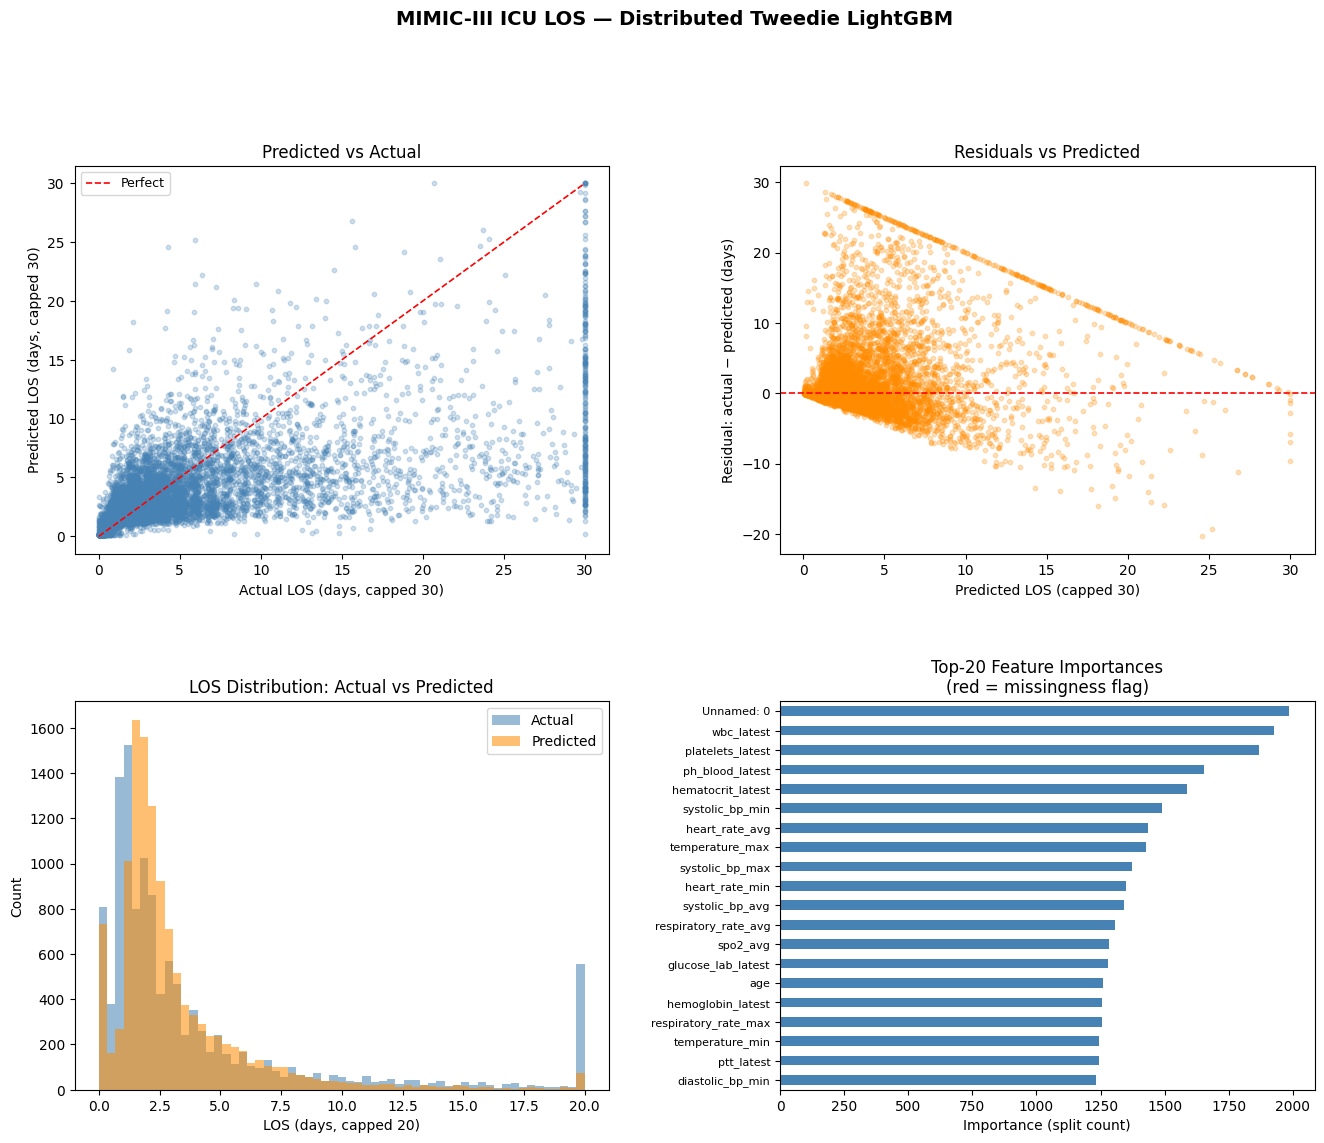

Saved → training_diagnostics.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Convert log predictions back to real days
y_true_days = np.expm1(y_test_log)
y_pred_days = np.expm1(np.clip(gbm_preds, 0, None))
residuals   = y_true_days - y_pred_days
cap = 30 # Matching your target clipping

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

# Panel 0: Predicted vs Actual
ax0 = fig.add_subplot(gs[0, 0])
ax0.scatter(np.clip(y_true_days, 0, cap), np.clip(y_pred_days, 0, cap),
            alpha=0.25, s=10, color="steelblue", rasterized=True)
ax0.plot([0, cap], [0, cap], "r--", linewidth=1.2, label="Perfect")
ax0.set(xlabel="Actual LOS (days, capped 30)", ylabel="Predicted LOS (days, capped 30)",
        title="Predicted vs Actual")
ax0.legend(fontsize=9)

# Panel 1: Residuals vs Predicted
ax1 = fig.add_subplot(gs[0, 1])
ax1.scatter(np.clip(y_pred_days, 0, cap), np.clip(residuals, -cap, cap),
            alpha=0.25, s=10, color="darkorange", rasterized=True)
ax1.axhline(0, color="red", linestyle="--", linewidth=1.2)
ax1.set(xlabel="Predicted LOS (capped 30)", ylabel="Residual: actual − predicted (days)",
        title="Residuals vs Predicted")

# Panel 2: LOS distribution
ax2 = fig.add_subplot(gs[1, 0])
bins = np.linspace(0, 20, 60)
ax2.hist(np.clip(y_true_days, 0, 20), bins=bins, alpha=0.55, label="Actual",    color="steelblue")
ax2.hist(np.clip(y_pred_days, 0, 20), bins=bins, alpha=0.55, label="Predicted", color="darkorange")
ax2.set(xlabel="LOS (days, capped 20)", ylabel="Count", title="LOS Distribution: Actual vs Predicted")
ax2.legend()

# Panel 3: Feature importances
ax3 = fig.add_subplot(gs[1, 1])
top20  = feat_imp.head(20)
colors = ["#d62728" if "Missing" in f else "steelblue" for f in top20.index]
top20.sort_values().plot.barh(ax=ax3, color=colors[::-1])
ax3.set(xlabel="Importance (split count)",
        title="Top-20 Feature Importances\n(red = missingness flag)")
ax3.tick_params(axis="y", labelsize=8)

fig.suptitle(f"MIMIC-III ICU LOS — Distributed Tweedie LightGBM", fontsize=14, fontweight="bold", y=1.01)
plt.savefig("training_diagnostics.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → training_diagnostics.png")

## Step 5 — Feature Selection

### Permutation Importance
Trains the model **once**, then for each feature in turn it **shuffles (permutes) that column** on the test set and re-measures MAE.  
- If MAE barely moves → the feature is useless.  
- If MAE skyrockets → the feature is vital.  

This approach is immune to correlated-feature bias because it measures **real-world predictive impact**, not split counts.  
Trade-off is that it runs one prediction pass per feature, so it is heavier for very wide datasets.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Permutation Importance
# ═══════════════════════════════════════════════════════════════════════════════
# Strategy:
#   1. Train the model ONCE (reuses `gbm` / best_gbm from Step 3).
#   2. For every feature column, shuffle (permute) its values in the TEST set.
#   3. Re-predict and measure how much MAE increases.
#      - No change  → the feature is useless (model ignored it).
#      - Large jump → the feature is vital.
#   4. Drop features whose importance falls below a threshold.
#
# Why this beats native importance:
#   Native split-count scores are biased for correlated features — LightGBM may
#   randomly assign all credit to HeartRate_Avg and zero to HeartRate_Max even
#   though both carry signal.  Permutation importance measures the *actual*
#   predictive impact, so correlated features are treated fairly.
#
#  Cost: one prediction pass per feature.  On 60 k rows × ~100 features this
#    typically takes 10–60 seconds — still very manageable.
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── CONFIG ────────────────────────────────────────────────────────────────────
PERM_N_REPEATS      = 5     # shuffle each feature this many times and average
                            # → reduces variance from a single unlucky shuffle
PERM_DROP_THRESHOLD = 0.0   # drop features with mean importance ≤ 0
                            
PERM_TOP_N_PLOT     = 25    # how many features to show in the bar chart
# ─────────────────────────────────────────────────────────────────────────────

# Use the best model and full feature set from Step 3
eval_model  = gbm           # `gbm` is reassigned to best_gbm at the end of Step 3
X_eval      = X_test_pd.copy()
y_eval_log  = y_true_log    # numpy array, already computed

# Baseline MAE on the unshuffled test set
base_preds   = eval_model.predict(X_eval)
base_mae     = np.mean(np.abs(y_eval_log - base_preds))
print(f"Baseline MAE (log-space): {base_mae:.4f}")
print(f"Running permutation importance ({PERM_N_REPEATS} repeats × {X_eval.shape[1]} features)...")
print(f"{'─'*55}")

perm_results = {}

for col in X_eval.columns:
    deltas = []
    original = X_eval[col].to_numpy().copy()

    for _ in range(PERM_N_REPEATS):
        # Shuffle the column in-place
        X_eval[col] = np.random.permutation(original)

        # Re-predict and measure the damage
        perm_preds = eval_model.predict(X_eval)
        perm_mae   = np.mean(np.abs(y_eval_log - perm_preds))
        deltas.append(perm_mae - base_mae)  # positive = feature was helping

    # Restore the column
    X_eval[col] = original
    perm_results[col] = np.mean(deltas)

perm_imp = pd.Series(perm_results).sort_values(ascending=False)

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\nTop {PERM_TOP_N_PLOT} most important features (MAE increase when shuffled):")
print(f"{'─'*55}")
for feat, delta in perm_imp.head(PERM_TOP_N_PLOT).items():
    bar = '█' * int(max(delta, 0) / (perm_imp.max() + 1e-9) * 30)
    print(f"  {feat:<35} {delta:+.4f}  {bar}")

# ── Features to drop ──────────────────────────────────────────────────────────
to_drop = perm_imp[perm_imp <= PERM_DROP_THRESHOLD].index.tolist()
selected_features_perm = [c for c in X_eval.columns if c not in to_drop]

print(f"\n{'═'*55}")
print(f"  Features dropped (importance ≤ {PERM_DROP_THRESHOLD}): {len(to_drop)}")
if to_drop:
    for f in to_drop:
        print(f"    - {f}  ({perm_imp[f]:+.4f})")
print(f"  Features kept: {len(selected_features_perm)}")
print(f"{'═'*55}")

# ── Retrain on permutation-selected features ───────────────────────────────────
import lightgbm as lgb
perm_final = lgb.LGBMRegressor(
    objective        = "tweedie",
    tweedie_variance_power = best_params.get("tweedie_variance_power", 1.5),
    num_leaves       = best_params.get("num_leaves", 63),
    learning_rate    = best_params.get("learning_rate", 0.05),
    n_estimators     = 500,
    random_state     = RANDOM_STATE,
    n_jobs           = -1,
    verbosity        = -1,
)
perm_final.fit(X_train_pd[selected_features_perm], y_train_log)

pf_preds     = perm_final.predict(X_test_pd[selected_features_perm])
pf_mae_days  = np.mean(np.abs(np.expm1(y_true_log) - np.expm1(np.clip(pf_preds, 0, None))))
pf_median_ae = np.median(np.abs(np.expm1(y_true_log) - np.expm1(np.clip(pf_preds, 0, None))))

print(f"\n  Permutation Final ({len(selected_features_perm)} features)")
print(f"  {'MAE (days)':<24} {pf_mae_days:>8.3f} d")
print(f"  {'Median AE (days)':<24} {pf_median_ae:>8.3f} d")

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, max(6, PERM_TOP_N_PLOT * 0.35)))
top = perm_imp.head(PERM_TOP_N_PLOT).sort_values()
colors = ["#d62728" if v < 0 else "steelblue" for v in top]
top.plot.barh(ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Mean MAE increase when feature is shuffled (log-space)")
ax.set_title(
    f"Permutation Feature Importance — Top {PERM_TOP_N_PLOT}\n"
    f"(red bars = hurts model when removed; blue = helps or neutral)"
)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.savefig("permutation_importance.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → permutation_importance.png")
print(f"\n→ `selected_features_perm` contains {len(selected_features_perm)} features, ready to use in Step 3.")


Baseline MAE (log-space): 0.3779
Running permutation importance (5 repeats × 177 features)...
───────────────────────────────────────────────────────


## Save&Go

In [ ]:
import joblib

# Save the best model to your local drive
MODEL_PATH = "mimic_los_lgbm_model.pkl"
joblib.dump(gbm, MODEL_PATH)

print(f"Model successfully saved to {MODEL_PATH}")
print("Training phase is 100% complete!")

Model successfully saved to mimic_los_lgbm_model.pkl
Training phase is 100% complete!
